# Notebook - Field Sampler

In [1]:
import sys
import os
project_root = "" # set the root path
sys.path.insert(0, project_root)
from datetime import datetime

In [ ]:
import json
import torch
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from functions.helper import batch_wise_random_drop, obs_field_reconstruction, sampler_test_data_generator, sampler_checkpoint_load, sampler_training_visualizer
device = [i for i in range(torch.cuda.device_count())][0]
# torch.manual_seed(128)

### Sampler Parameters

In [4]:
stage = 2
obs_sample = 1730
secnario = "SHM"
mode = "latest" # ["latest","best","closest"] # Latest - best for testing in training progress; Closest - best for sampling after training process
path = os.listdir("../output/")[next((i for i, p in enumerate(os.listdir("../output/")) if secnario in str(p)), None)]
path = f"../output/{path}"
display(path)

'../output/SHM-2025-12-28-04-58-41'

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_latest.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 1730, 7])


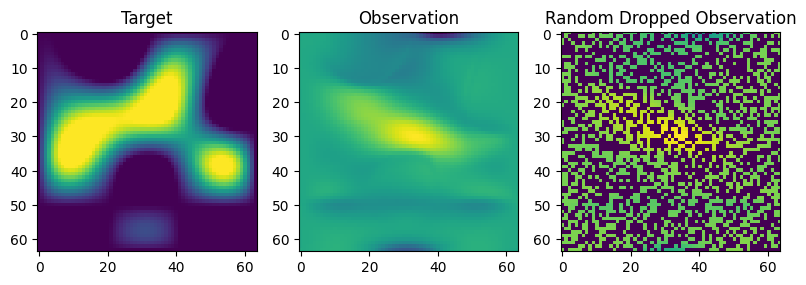

In [5]:
model, certainty_param = sampler_checkpoint_load(path, stage, obs_sample, mode, device)
target, obs, drop_obs, target_batch, obs_batch, drop_obs_batch = sampler_test_data_generator(path, stage, obs_sample, mode, device, shuffle=False, position=7)

### Field Sampler Generations

In [8]:
gen_field = []
for i in tqdm(range(7)):
    img = model.sample(shape=target.shape, steps=80, device="cuda", conditions=drop_obs)
    gen_field.append(img)

100%|██████████| 7/7 [00:08<00:00,  1.18s/it]


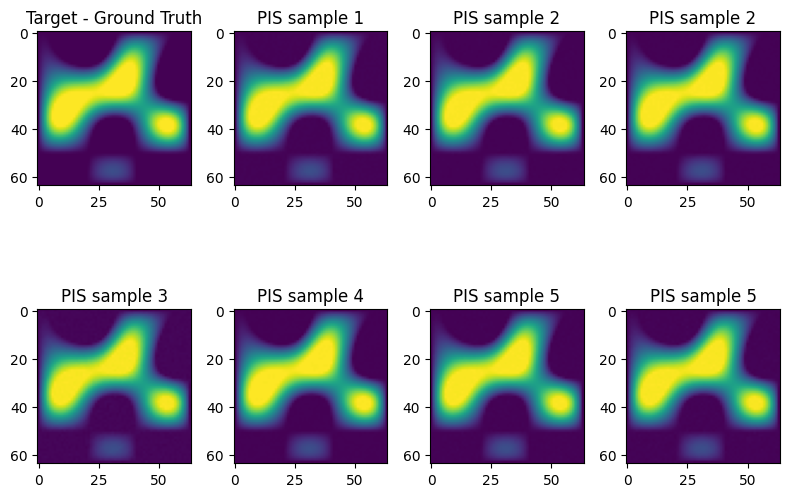

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(8, 6))

axes[0, 0].imshow(target.squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[0, 0].set_title('Target - Ground Truth')

axes[0, 1].imshow(gen_field[0].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[0, 1].set_title('PIS sample 1')

axes[0, 2].imshow(gen_field[1].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[0, 2].set_title('PIS sample 2')

axes[0, 3].imshow(gen_field[2].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[0, 3].set_title('PIS sample 2')

axes[1, 0].imshow(gen_field[3].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[1, 0].set_title('PIS sample 3')

axes[1, 1].imshow(gen_field[4].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[1, 1].set_title('PIS sample 4')

axes[1, 2].imshow(gen_field[5].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[1, 2].set_title('PIS sample 5')

axes[1, 3].imshow(gen_field[6].squeeze(0).squeeze(0).detach().cpu().numpy(), cmap="viridis")
axes[1, 3].set_title('PIS sample 5')

plt.tight_layout()

### Training Loss Details

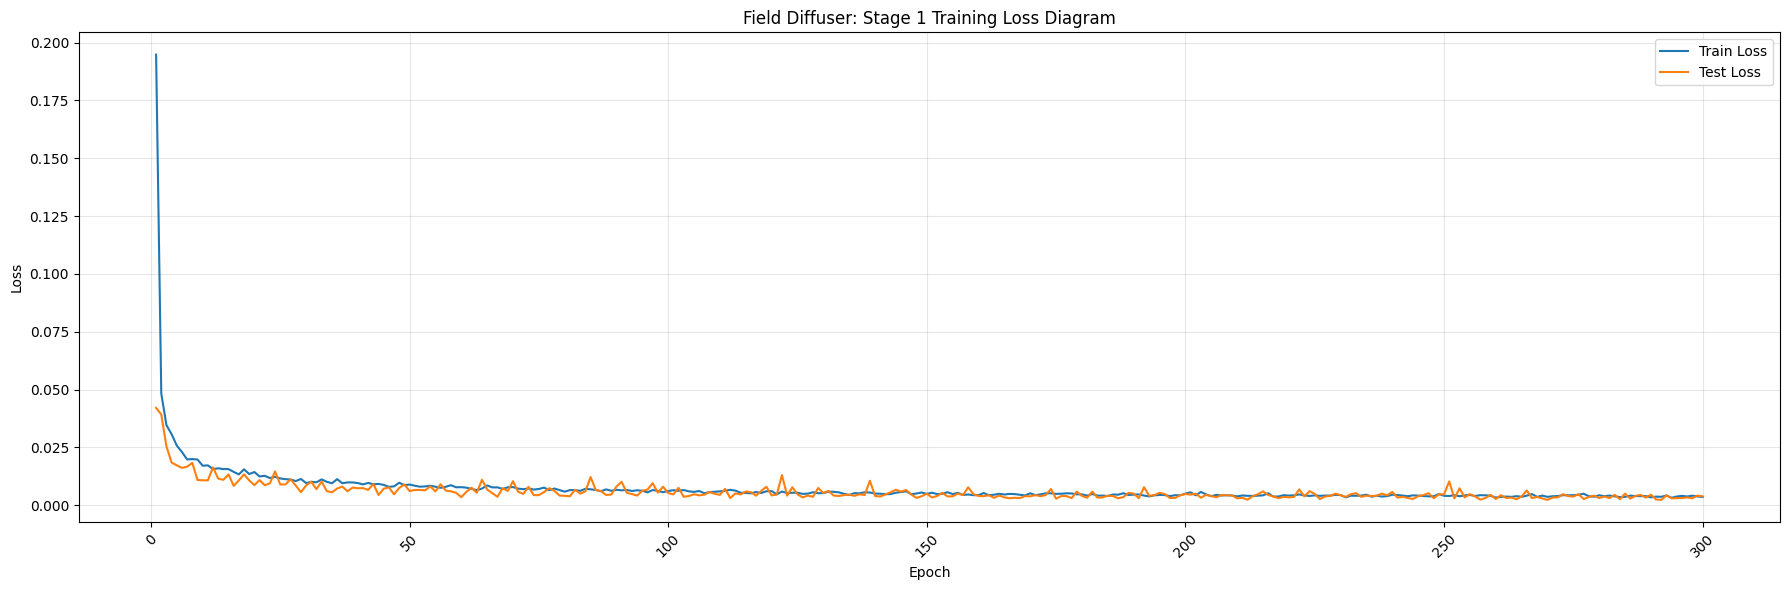

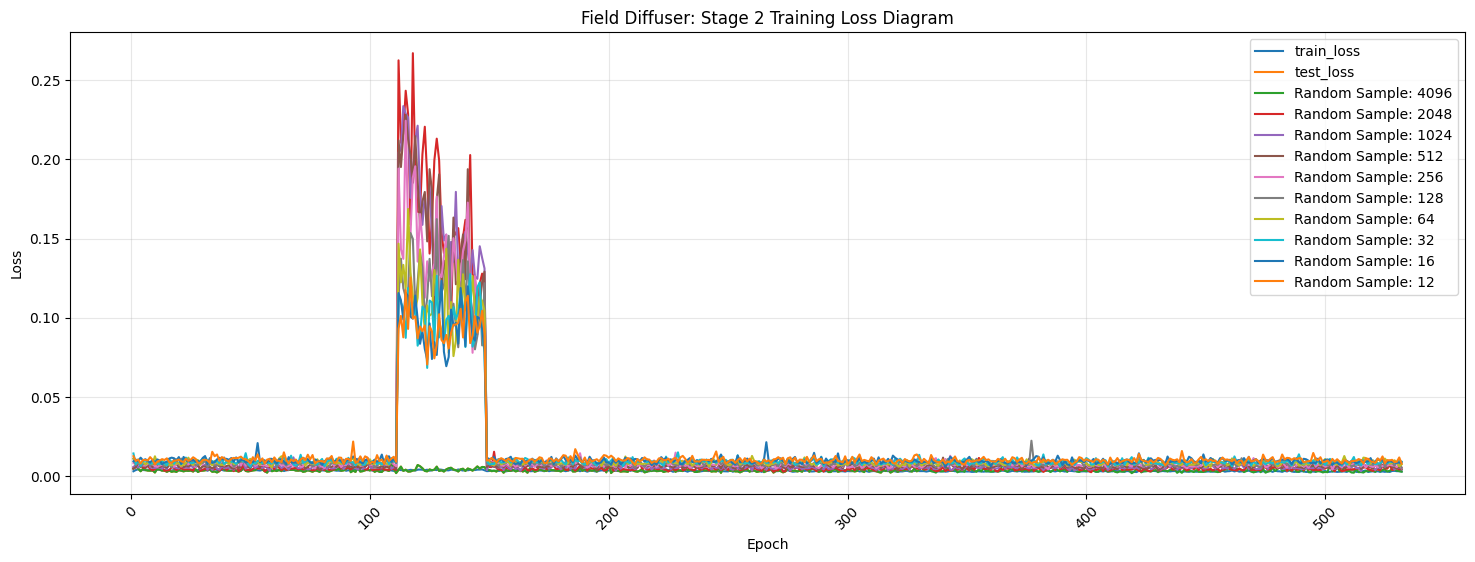

In [7]:
sampler_training_visualizer(path)